C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\1910401274.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Panic State Detected as: 1
Calm State Detected as: 0


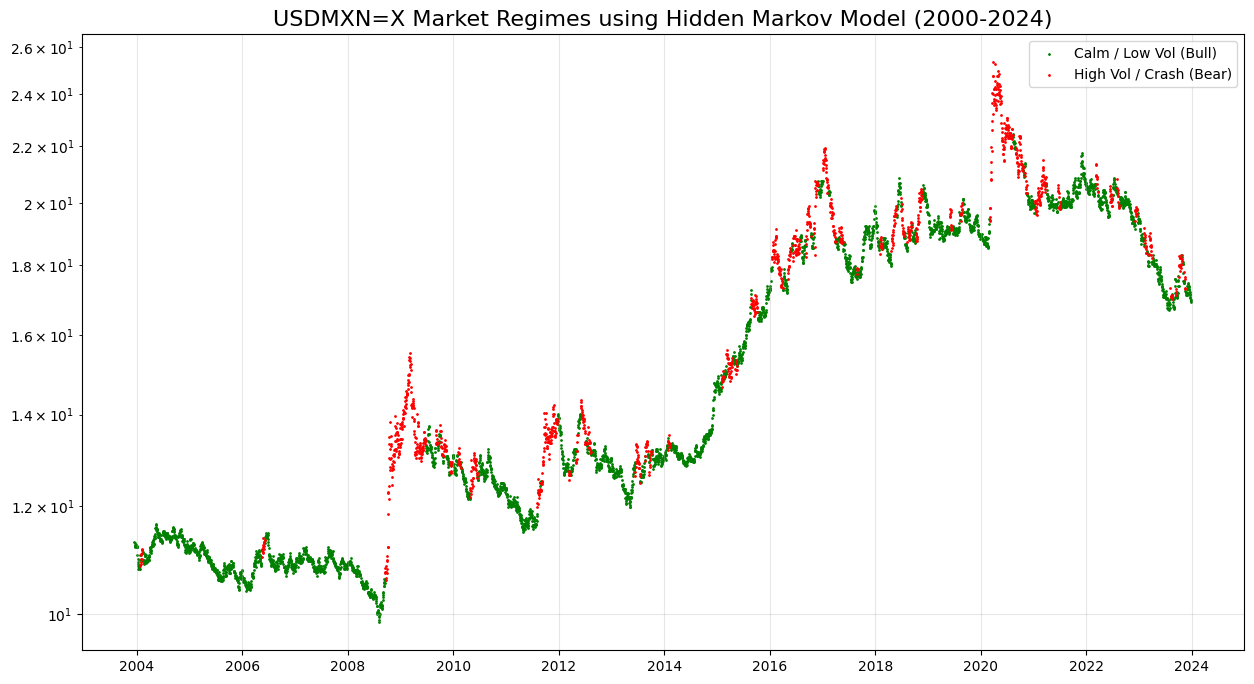


Transition Matrix:
Prob of staying in Calm: 98.31%
Prob of switching Calm -> Panic: 1.69%
Prob of staying in Panic: 95.04%
Prob of switching Panic -> Calm: 4.96%


In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. GET DATA
# Fetch S&P 500 data from 2000 to present to capture Dotcom, 2008, and Covid
ticker = "USDMXN=X"
data = yf.download(ticker, start="2000-01-01", end="2024-01-01")
data = data[['Close']].copy()

# 2. FEATURE ENGINEERING
# We need features that differentiate "Calm" from "Panic".
# Feature A: Daily Log Returns
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
# Feature B: Realized Volatility (10-day rolling standard deviation)
data['Volatility'] = data['Returns'].rolling(window=10).std()

# Drop NaN values created by the shift and rolling window
data.dropna(inplace=True)

# Prepare the data for the HMM (needs a 2D array)
# We scale returns by 100 to help the model converge (avoids tiny numbers)
X = np.column_stack([
    data['Returns'].values * 100, 
    data['Volatility'].values * 100
])

# 3. BUILD AND TRAIN HMM
# n_components=2 means we assume 2 regimes: "Calm" and "Volatile"
# covariance_type="diag" assumes features are independent (simplification)
model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000, random_state=42)
model.fit(X)

# Predict the hidden states (0 or 1) for each day
hidden_states = model.predict(X)

# 4. IDENTIFY REGIMES (Which is "Panic"?)
# The model labels states 0 and 1 randomly. We need to check which one is "Panic".
# "Panic" usually has higher volatility variance.
state_0_vol_mean = model.means_[0][1] # Mean volatility of State 0
state_1_vol_mean = model.means_[1][1] # Mean volatility of State 1

if state_0_vol_mean > state_1_vol_mean:
    panic_state = 0
    calm_state = 1
else:
    panic_state = 1
    calm_state = 0

print(f"Panic State Detected as: {panic_state}")
print(f"Calm State Detected as: {calm_state}")

# 5. VISUALIZATION
# Create a plot colored by regime
fig, ax = plt.subplots(figsize=(15, 8))

# Extract dates and prices aligned with our X data
dates = data.index
prices = data['Close'].values

# Plot the "Calm" segments in Green
# We use masks to plot only the points belonging to a specific state
mask_calm = (hidden_states == calm_state)
ax.scatter(dates[mask_calm], prices[mask_calm], c='green', s=1, label='Calm / Low Vol (Bull)')

# Plot the "Panic" segments in Red
mask_panic = (hidden_states == panic_state)
ax.scatter(dates[mask_panic], prices[mask_panic], c='red', s=1, label='High Vol / Crash (Bear)')

# Formatting
ax.set_title(f'{ticker} Market Regimes using Hidden Markov Model (2000-2024)', fontsize=16)
ax.set_yscale('log') # Log scale helps visualize long-term trends better
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2)) # Show year every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

# 6. STATISTICS
# Let's see the transition matrix (probability of switching states)
print("\nTransition Matrix:")
print(f"Prob of staying in Calm: {model.transmat_[calm_state][calm_state]:.2%}")
print(f"Prob of switching Calm -> Panic: {model.transmat_[calm_state][panic_state]:.2%}")
print(f"Prob of staying in Panic: {model.transmat_[panic_state][panic_state]:.2%}")
print(f"Prob of switching Panic -> Calm: {model.transmat_[panic_state][calm_state]:.2%}")

C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\1692722617.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="1993-01-01", progress=False)


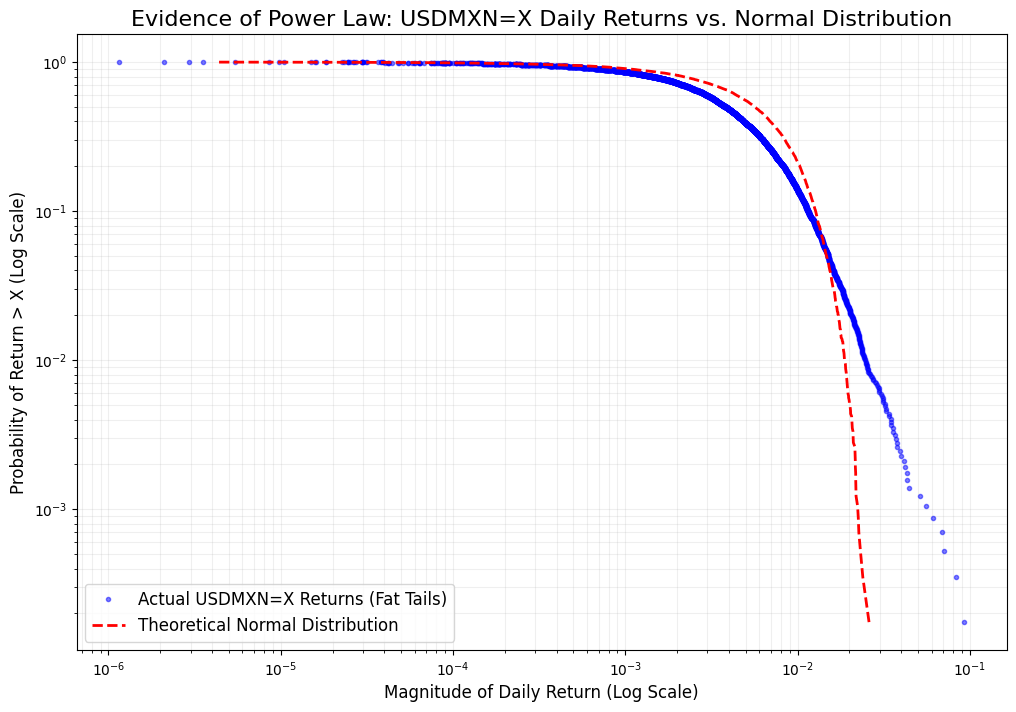

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. GET DATA
# We fetch SPY data from 1993 (inception) to maximize the number of crashes captured
ticker = "USDMXN=X"
print(f"Downloading {ticker} data...")
data = yf.download(ticker, start="1993-01-01", progress=False)

# 2. CALCULATE LOG RETURNS
# We use Log Returns because they are theoretically unbounded
# We take the Absolute Value because we care about the "Magnitude" of volatility (up or down)
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()
returns = np.abs(data['Log_Returns'].values) # Absolute magnitude (Fat tails exist on both sides)

# Remove zero returns to avoid log(0) errors in plotting
returns = returns[returns > 0]

# 3. PREPARE DATA FOR CCDF (Survival Function)
# Sort data from smallest to largest
sorted_returns = np.sort(returns)
# Calculate the probability of being greater than X
# y = 1, 0.99, 0.98 ... down to 0
y_vals = 1.0 - np.arange(len(sorted_returns)) / len(sorted_returns)

# 4. GENERATE A THEORETICAL NORMAL DISTRIBUTION (THE BENCHMARK)
# We generate fake data with the SAME mean and std dev as SPY, but Normally distributed.
mean = np.mean(returns)
std_dev = np.std(returns)
normal_sim = np.random.normal(mean, std_dev, len(returns))
normal_sim = np.abs(normal_sim) # Absolute value for comparison
normal_sim = normal_sim[normal_sim > 0]
sorted_normal = np.sort(normal_sim)
y_normal = 1.0 - np.arange(len(sorted_normal)) / len(sorted_normal)

# 5. PLOT THE LOG-LOG GRAPH
plt.figure(figsize=(12, 8))

# Plot SPY Data (Blue)
plt.plot(sorted_returns, y_vals, marker='.', linestyle='none', color='blue', alpha=0.5, label=f'Actual {ticker} Returns (Fat Tails)')

# Plot Normal Distribution (Red Dashed)
plt.plot(sorted_normal, y_normal, linestyle='--', color='red', linewidth=2, label='Theoretical Normal Distribution')

# Set Scales to Log-Log
plt.xscale('log')
plt.yscale('log')

# Formatting
plt.title(f'Evidence of Power Law: {ticker} Daily Returns vs. Normal Distribution', fontsize=16)
plt.xlabel('Magnitude of Daily Return (Log Scale)', fontsize=12)
plt.ylabel('Probability of Return > X (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=12)

# Annotation to help read the graph
plt.annotate('The "Fat Tail"\n(Events that "shouldn\'t" happen)', 
             xy=(0.04, 0.0001), 
             xytext=(0.01, 0.00001),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\3925367680.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)


Calm State is: 0
Panic State is: 1


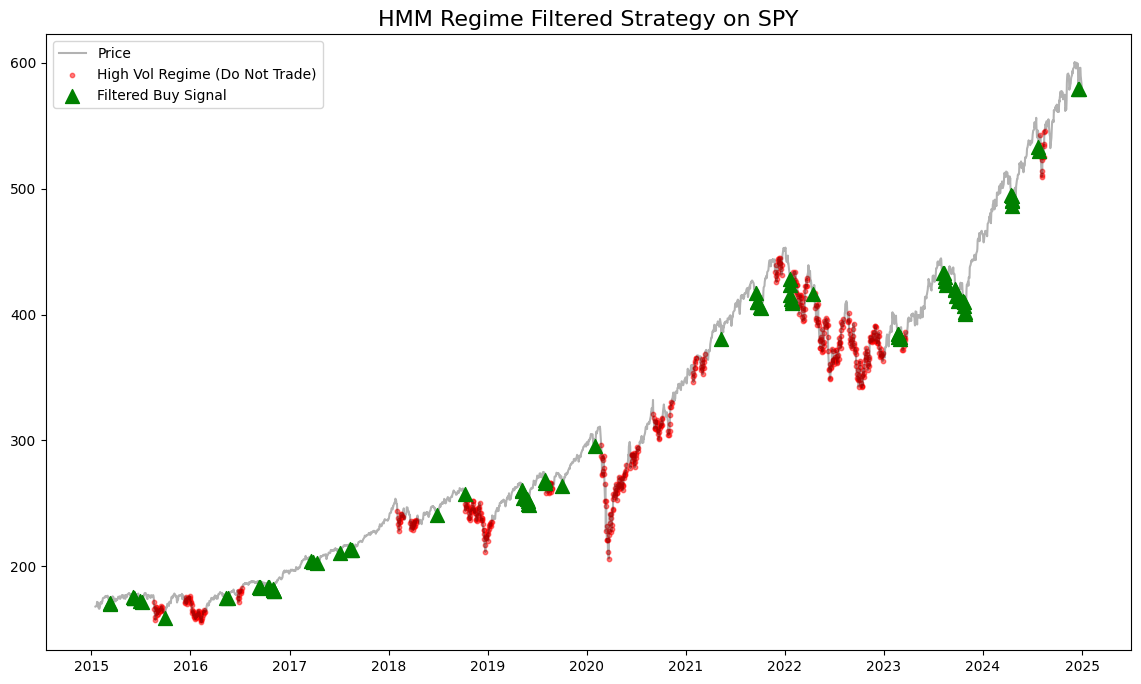

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. GET DATA
ticker = "SPY" # Using SPY as it has clear regimes
df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].copy()

# 2. FEATURE ENGINEERING FOR TRADING
# We use Log Returns for the math
df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

# We use Rolling Volatility as a feature for the HMM
# (HMM distinguishes regimes better if it knows recent volatility)
df["volatility"] = df["log_ret"].rolling(window=10).std()

# Drop NaNs
df.dropna(inplace=True)

# 3. TRAIN HMM (THE REGIME DETECTOR)
# We feed it Returns and Volatility
X = np.column_stack([df["log_ret"], df["volatility"]])

# Train the model (2 components: Calm vs. Volatile)
hmm_model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000, random_state=42)
hmm_model.fit(X)

# Predict the hidden states (0 or 1)
df["hmm_state"] = hmm_model.predict(X)

# 4. IDENTIFY WHICH STATE IS "HIGH VOLATILITY"
# The model randomly labels states 0 or 1. We need to know which one is the "Panic" state.
# We check which state has the higher average volatility.
state_0_vol = df[df["hmm_state"] == 0]["volatility"].mean()
state_1_vol = df[df["hmm_state"] == 1]["volatility"].mean()

if state_0_vol > state_1_vol:
    panic_state = 0
    calm_state = 1
else:
    panic_state = 1
    calm_state = 0

print(f"Calm State is: {calm_state}")
print(f"Panic State is: {panic_state}")

# 5. DEFINE TRADING STRATEGY (ROBUST MEAN REVERSION)
# Rule: Buy if price is in the bottom 5% of the last 20 days
window = 20
df["lower_quantile"] = df["Close"].rolling(window).quantile(0.05)

# SIGNAL 1: The Technical Signal (Price is cheap)
df["signal_cheap"] = (df["Close"] < df["lower_quantile"])

# SIGNAL 2: The Regime Filter (Market is Calm)
df["signal_regime"] = (df["hmm_state"] == calm_state)

# FINAL SIGNAL: Combine them
# We ONLY buy if it is Cheap AND Calm
df["entry"] = (df["signal_cheap"] & df["signal_regime"]).astype(int)

# 6. VISUALIZATION
plt.figure(figsize=(14, 8))

# Plot Price
plt.plot(df.index, df["Close"], color='black', alpha=0.3, label='Price')

# Highlight Panic Regimes (Red Zones)
# We fill the background red where HMM says "Panic"
y_min, y_max = df["Close"].min(), df["Close"].max()
panic_dates = df.index[df["hmm_state"] == panic_state]
# (Plotting bars for panic is tricky, simplified by just coloring the dots)
plt.scatter(df.index[df["hmm_state"] == panic_state], 
            df["Close"][df["hmm_state"] == panic_state], 
            color='red', s=10, label='High Vol Regime (Do Not Trade)', alpha=0.5)

# Plot Buy Signals (Green Triangles)
# These are the trades that PASSED the filter
buys = df[df["entry"] == True]
plt.scatter(buys.index, buys["Close"], marker='^', color='green', s=100, label='Filtered Buy Signal', zorder=5)

plt.title(f"HMM Regime Filtered Strategy on {ticker}", fontsize=16)
plt.legend()
plt.show()

Training HMM...

RESULTS FOR SPY (2010-2025)
Total Return:    15.47%
Buy & Hold Ret:  579.42%
Annualized Ret:  0.97%
Sharpe Ratio:    0.34
Max Drawdown:    -9.47%
Win Rate:        56.00%


C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\3829555547.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2010-01-01", end="2025-01-01", progress=False)


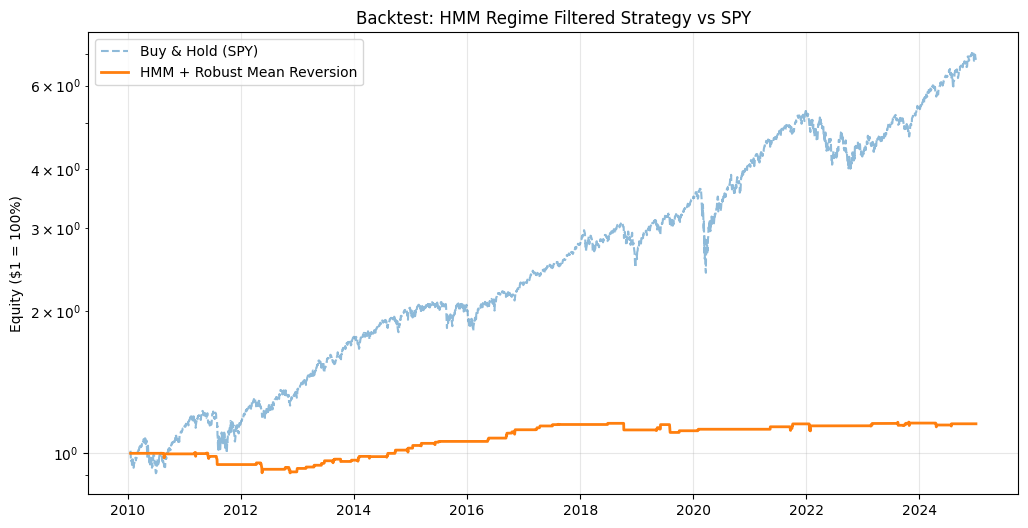

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# --- 1. DATA LOADING & FIXES ---
ticker = "SPY"
print(f"Downloading data for {ticker}...")
df = yf.download(ticker, start="2010-01-01", end="2025-01-01", progress=False)

# FIX: Flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
    
df = df[['Close']].copy()

# --- 2. INDICATORS & HMM SETUP ---
# Log Returns for HMM
df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))
# Simple Returns for PnL calculation
df["pct_change"] = df["Close"].pct_change()
# Volatility for HMM
df["volatility"] = df["log_ret"].rolling(window=10).std()

df.dropna(inplace=True)

# --- 3. TRAIN HMM (Regime Detection) ---
print("Training HMM...")
X = np.column_stack([df["log_ret"], df["volatility"]])
hmm_model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000, random_state=42)
hmm_model.fit(X)
df["hmm_state"] = hmm_model.predict(X)

# Identify which state is "Calm" vs "Panic"
state_0_vol = df[df["hmm_state"] == 0]["volatility"].mean()
state_1_vol = df[df["hmm_state"] == 1]["volatility"].mean()
calm_state = 1 if state_0_vol > state_1_vol else 0

# --- 4. STRATEGY SIGNALS (Robust Mean Reversion) ---
window = 20
# Define "Cheap": Bottom 5% of recent price action
df["lower_quantile"] = df["Close"].rolling(window).quantile(0.05)

# Condition A: Price is Cheap
signal_cheap = (df["Close"] < df["lower_quantile"])
# Condition B: Regime is Calm (HMM Filter)
signal_calm = (df["hmm_state"] == calm_state)

# COMBINED SIGNAL: Buy only when Cheap AND Calm
df["long_signal"] = signal_cheap & signal_calm

# --- 5. CALCULATE PERFORMANCE (PnL) ---

# We enter at the Close of the signal day, so we get the return of the NEXT day.
# shift(1) moves the signal down, so it aligns with tomorrow's return.
df["strategy_return"] = df["long_signal"].astype(int).shift(1) * df["pct_change"]

# Cumulative Returns (Equity Curve)
df["cumulative_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cumulative_market"] = (1 + df["pct_change"]).cumprod()

# --- 6. METRICS ---
total_days = len(df)
# Annualized Return
cagr = (df["cumulative_strategy"].iloc[-1]) ** (252/total_days) - 1
# Sharpe Ratio (assuming 0% risk free for simplicity)
sharpe = (df["strategy_return"].mean() / df["strategy_return"].std()) * np.sqrt(252)
# Max Drawdown
rolling_max = df["cumulative_strategy"].cummax()
drawdown = (df["cumulative_strategy"] - rolling_max) / rolling_max
max_drawdown = drawdown.min()
# Win Rate
wins = df[df["strategy_return"] > 0]
losses = df[df["strategy_return"] < 0]
win_rate = len(wins) / (len(wins) + len(losses))

print("\n" + "="*30)
print(f"RESULTS FOR {ticker} (2010-2025)")
print("="*30)
print(f"Total Return:    {(df['cumulative_strategy'].iloc[-1] - 1)*100:.2f}%")
print(f"Buy & Hold Ret:  {(df['cumulative_market'].iloc[-1] - 1)*100:.2f}%")
print(f"Annualized Ret:  {cagr*100:.2f}%")
print(f"Sharpe Ratio:    {sharpe:.2f}")
print(f"Max Drawdown:    {max_drawdown*100:.2f}%")
print(f"Win Rate:        {win_rate*100:.2f}%")
print("="*30)

# --- 7. PLOTTING ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["cumulative_market"], label="Buy & Hold (SPY)", alpha=0.5, linestyle='--')
plt.plot(df.index, df["cumulative_strategy"], label="HMM + Robust Mean Reversion", linewidth=2)
plt.title(f"Backtest: HMM Regime Filtered Strategy vs SPY")
plt.ylabel("Equity ($1 = 100%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Log scale is better for long timeframes
plt.show()

C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\1604634186.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2000-01-01", end="2025-01-01", progress=False)



RISK ON/OFF STRATEGY RESULTS
Strategy Return: 39206.12%
Buy & Hold Ret:  159871.32%
Max Drawdown:    -79.72%
Sharpe Ratio:    0.88


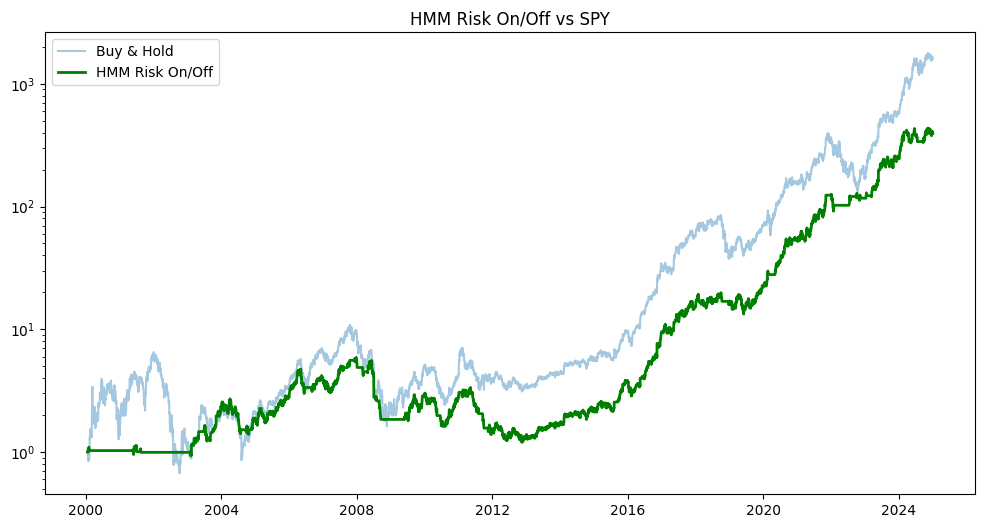

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. GET DATA
ticker = "NVDA"
df = yf.download(ticker, start="2000-01-01", end="2025-01-01", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].copy()

# 2. FEATURES
df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))
df["pct_change"] = df["Close"].pct_change()
df["volatility"] = df["log_ret"].rolling(window=10).std()
df.dropna(inplace=True)

# 3. TRAIN HMM
X = np.column_stack([df["log_ret"], df["volatility"]])
hmm_model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000, random_state=42)
hmm_model.fit(X)
df["hmm_state"] = hmm_model.predict(X)

# Identify Regimes
state_0_vol = df[df["hmm_state"] == 0]["volatility"].mean()
state_1_vol = df[df["hmm_state"] == 1]["volatility"].mean()
calm_state = 1 if state_0_vol > state_1_vol else 0

# --- 4. THE STRATEGY PIVOT ---
# OLD STRATEGY: Buy only if Calm AND Cheap (Too picky)
# NEW STRATEGY: If Calm -> 100% Long. If Panic -> Cash.

df["position"] = 0 # Default to Cash

# RULE: Be Long whenever HMM says "Calm"
df.loc[df["hmm_state"] == calm_state, "position"] = 1 

# OPTIONAL: You can add "Short" during Panic if you are aggressive
# df.loc[df["hmm_state"] != calm_state, "position"] = -1 

# --- 5. CALCULATE RETURNS ---
# We shift position by 1 because we make the decision at Close, 
# and get the return of the Next Day.
df["strategy_return"] = df["position"].shift(1) * df["pct_change"]

# Cumulative Stats
df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cum_market"] = (1 + df["pct_change"]).cumprod()

# --- 6. RESULTS ---
total_ret = (df['cum_strategy'].iloc[-1] - 1) * 100
market_ret = (df['cum_market'].iloc[-1] - 1) * 100
max_dd = ((df["cum_strategy"] - df["cum_strategy"].cummax()) / df["cum_strategy"].cummax()).min() * 100
sharpe = (df["strategy_return"].mean() / df["strategy_return"].std()) * np.sqrt(252)

print("\n" + "="*30)
print(f"RISK ON/OFF STRATEGY RESULTS")
print("="*30)
print(f"Strategy Return: {total_ret:.2f}%")
print(f"Buy & Hold Ret:  {market_ret:.2f}%")
print(f"Max Drawdown:    {max_dd:.2f}%")
print(f"Sharpe Ratio:    {sharpe:.2f}")
print("="*30)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["cum_market"], label="Buy & Hold", alpha=0.4)
plt.plot(df.index, df["cum_strategy"], label="HMM Risk On/Off", linewidth=2, color='green')
plt.yscale('log')
plt.legend()
plt.title("HMM Risk On/Off vs SPY")
plt.show()

Analyzing NVDA...

MODIFIED STRATEGY FOR NVDA
Strategy Return: 14651.44%
Buy & Hold Ret:  24990.34%
Max Drawdown:    -39.53%


C:\Users\gui_k\AppData\Local\Temp\ipykernel_22928\2722399666.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)


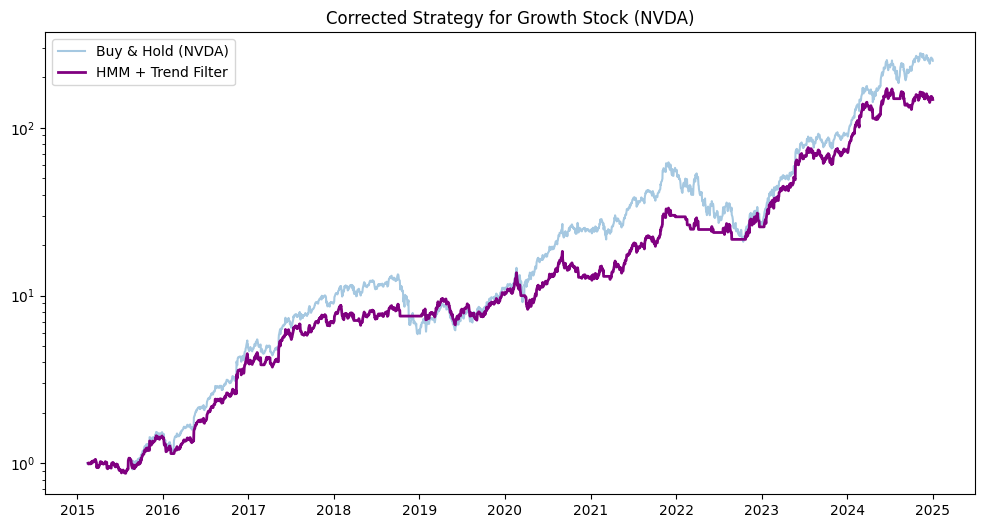

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. GET DATA (NVDA)
ticker = "NVDA"
print(f"Analyzing {ticker}...")
df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].copy()

# 2. FEATURE ENGINEERING
df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))
df["pct_change"] = df["Close"].pct_change()
df["volatility"] = df["log_ret"].rolling(window=10).std()
# NEW FEATURE: The Trend (200-Day Moving Average)
df["ma_200"] = df["Close"].rolling(window=30).mean()

df.dropna(inplace=True)

# 3. TRAIN HMM (Same as before)
X = np.column_stack([df["log_ret"], df["volatility"]])
hmm_model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000, random_state=42)
hmm_model.fit(X)
df["hmm_state"] = hmm_model.predict(X)

# Identify Regimes
state_0_vol = df[df["hmm_state"] == 0]["volatility"].mean()
state_1_vol = df[df["hmm_state"] == 1]["volatility"].mean()
calm_state = 1 if state_0_vol > state_1_vol else 0
panic_state = 1 - calm_state

# --- 4. THE MODIFIED LOGIC (DIRECTIONAL HMM) ---

# Logic:
# 1. If HMM == Calm: LONG (Standard)
# 2. If HMM == Panic AND Price > 200 MA: LONG (Assume it's a "Good Volatility" Rally)
# 3. If HMM == Panic AND Price < 200 MA: CASH (Assume it's a Crash)

df["position"] = 0 # Default Cash

# Condition 1: Calm State -> Long
df.loc[df["hmm_state"] == calm_state, "position"] = 1

# Condition 2: Panic State BUT Strong Trend -> Long (Riding the Bubble)
bullish_panic = (df["hmm_state"] == panic_state) & (df["Close"] > df["ma_200"])
df.loc[bullish_panic, "position"] = 1 

# (Condition 3 is implicit: Panic + Below MA stays 0/Cash)

# --- 5. PERFORMANCE ---
df["strategy_return"] = df["position"].shift(1) * df["pct_change"]
df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cum_market"] = (1 + df["pct_change"]).cumprod()

# Stats
total_ret = (df['cum_strategy'].iloc[-1] - 1) * 100
market_ret = (df['cum_market'].iloc[-1] - 1) * 100
max_dd = ((df["cum_strategy"] - df["cum_strategy"].cummax()) / df["cum_strategy"].cummax()).min() * 100

print("\n" + "="*30)
print(f"MODIFIED STRATEGY FOR {ticker}")
print("="*30)
print(f"Strategy Return: {total_ret:.2f}%")
print(f"Buy & Hold Ret:  {market_ret:.2f}%")
print(f"Max Drawdown:    {max_dd:.2f}%")
print("="*30)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["cum_market"], label=f"Buy & Hold ({ticker})", alpha=0.4)
plt.plot(df.index, df["cum_strategy"], label="HMM + Trend Filter", linewidth=2, color='purple')
plt.yscale('log')
plt.legend()
plt.title(f"Corrected Strategy for Growth Stock ({ticker})")
plt.show()